# 02 · Problema supervisionado, divisão treino/teste e baseline

**Painel de Equidade em Saúde do Recife** · Projeto 3 + Machine Learning I

> ⚠️ **Base sintética** (ver `docs/contrato_dados.md`).

## O problema de Machine Learning

| | |
|---|---|
| **Tipo** | Classificação binária supervisionada |
| **Unidade de análise** | Equipe de Saúde da Família × quadrimestre |
| **Pergunta** | Olhando a equipe até o quadrimestre *t*, ela vai estar **crítica** em *t+1*? |
| **Alvo** (`critica_prox`) | 1 se a equipe estiver entre as **25% piores** no índice de completude do quadrimestre seguinte |
| **Por que prever e não só medir** | Medir mostra quem está mal hoje. Prever mostra quem vai estar, e a Secretaria planeja a formação antes |
| **Métrica principal** | **Recall e F1 da classe "crítica"**: deixar passar uma equipe crítica custa mais que um alerta a mais |

Pipeline até aqui: `gerar_sintetico.py` → `tratamento.py` → `indicadores.py` → `features.py` → `baseline.py`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ / "src"))
from features import ALVO, VARIAVEIS
from baseline import TESTE, TREINO, avaliar, dividir

FIGURAS = RAIZ / "notebooks" / "figuras"
AZUL, LARANJA, VERDE_AGUA, AMARELO = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
CINZA, TEXTO, TEXTO_2, FUNDO = "#b5b4ae", "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": FUNDO, "axes.facecolor": FUNDO, "savefig.facecolor": FUNDO,
    "axes.edgecolor": CINZA, "axes.labelcolor": TEXTO_2, "xtick.color": TEXTO_2, "ytick.color": TEXTO_2,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e8e7e3",
    "grid.linewidth": 0.8, "axes.axisbelow": True, "font.size": 10, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "figure.dpi": 110,
})
salvar = lambda fig, nome: fig.savefig(FIGURAS / f"{nome}.png", dpi=150, bbox_inches="tight")

base = pd.read_parquet(RAIZ / "data" / "processed" / "base_modelo.parquet")
print(f"{len(base):,} linhas · {base['ine'].nunique()} equipes · quadrimestres {base['quadrimestre'].min()} a {base['quadrimestre'].max()}")

2,688 linhas · 384 equipes · quadrimestres 2024.2 a 2026.2


## 1. As variáveis

Toda variável da linha *t* usa **só informação disponível até o fim de *t***. O quadrimestre seguinte aparece apenas no alvo. Isso evita **vazamento de dados** (o modelo "ver o futuro" durante o treino).

In [2]:
descricao = {
    "indice_completude": "Índice de completude no quadrimestre (0 a 100)",
    "posicao_na_rede": "Posição da equipe na rede no quadrimestre (0 = pior, 1 = melhor)",
    "critica": "Está crítica agora (1/0)",
    "os_preenchido": "% com orientação sexual informada",
    "os_recusou": "% que recusou informar orientação sexual",
    "os_nao_perguntado": "% em que orientação sexual não foi perguntada",
    "ig_preenchido": "% com identidade de gênero informada",
    "raca_preenchido": "% com raça/cor preenchida",
    "deficiencia_preenchido": "% com deficiência preenchida",
    "indice_anterior": "Índice no quadrimestre anterior",
    "variacao_indice": "Variação do índice em relação ao anterior",
    "media_historica": "Média do índice em todo o histórico até agora",
    "fracao_critica": "Fração dos quadrimestres em que foi crítica",
    "n_fichas": "Nº de fichas enviadas no quadrimestre",
    "inconsistencia_raca": "Pontos de brancos/amarelos acima da mediana do distrito (erro de raça/cor)",
}
tabela = pd.DataFrame({"descrição": descricao})
tabela.loc["ds_1 ... ds_8", "descrição"] = "Distrito Sanitário (uma coluna 0/1 por distrito)"
tabela

,descrição
indice_completude,Índice de completude no quadrimestre (0 a 100)
posicao_na_rede,Posição da equipe na rede no quadrimestre (0 =...
critica,Está crítica agora (1/0)
os_preenchido,% com orientação sexual informada
os_recusou,% que recusou informar orientação sexual
os_nao_perguntado,% em que orientação sexual não foi perguntada
ig_preenchido,% com identidade de gênero informada
raca_preenchido,% com raça/cor preenchida
deficiencia_preenchido,% com deficiência preenchida
indice_anterior,Índice no quadrimestre anterior


In [3]:
base[VARIAVEIS[:15]].describe().T.round(2)[["mean", "std", "min", "50%", "max"]]

,mean,std,min,50%,max
indice_completude,59.48,10.86,33.71,61.06,80.80
posicao_na_rede,0.50,0.29,0.00,0.50,1.00
critica,0.25,0.43,0.00,0.00,1.00
os_preenchido,0.38,0.16,0.01,0.40,0.70
os_recusou,0.21,0.09,0.01,0.21,0.41
os_nao_perguntado,0.41,0.24,0.00,0.38,0.98
ig_preenchido,0.42,0.17,0.01,0.45,0.78
raca_preenchido,0.98,0.02,0.85,0.99,1.00
deficiencia_preenchido,0.98,0.03,0.78,0.98,1.00
indice_anterior,59.58,10.43,34.94,61.00,80.80


## 2. Divisão treino/teste: temporal, não aleatória

Se as linhas fossem sorteadas, o modelo poderia treinar com o quadrimestre de 2026 de uma equipe e ser testado em 2025 da mesma equipe, ou seja, aprender com o futuro. Na vida real, a Secretaria só tem o passado para prever o próximo período. Por isso: **treino com os quadrimestres mais antigos, teste com os mais recentes.**

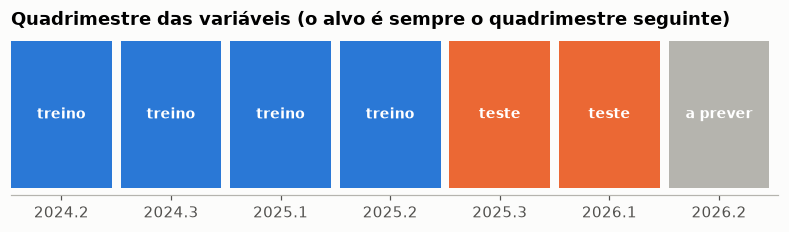

,linhas,% do total rotulado,% críticas no alvo,quadrimestres (variáveis)
treino,1536,66.7,25.0,"2024.2, 2024.3, 2025.1, 2025.2"
teste,768,33.3,25.0,"2025.3, 2026.1"


In [4]:
treino, teste = dividir(base)
ordem = sorted(base["quadrimestre"].unique())

fig, ax = plt.subplots(figsize=(9, 1.9))
for i, q in enumerate(ordem):
    if q in TREINO:
        cor, rotulo = AZUL, "treino"
    elif q in TESTE:
        cor, rotulo = LARANJA, "teste"
    else:
        cor, rotulo = CINZA, "a prever"
    ax.barh(0, 0.92, left=i, color=cor, height=0.5)
    ax.text(i + 0.46, 0, rotulo, ha="center", va="center", color="white", fontsize=9, fontweight="bold")
ax.set_xticks(np.arange(len(ordem)) + 0.46, ordem)
ax.set_yticks([])
ax.set_xlim(0, len(ordem))
ax.grid(False)
ax.spines["left"].set_visible(False)
ax.set_title("Quadrimestre das variáveis (o alvo é sempre o quadrimestre seguinte)")
salvar(fig, "08_divisao_temporal")
plt.show()

resumo_split = pd.DataFrame({
    "linhas": [len(treino), len(teste)],
    "% do total rotulado": [len(treino) / (len(treino) + len(teste)) * 100, len(teste) / (len(treino) + len(teste)) * 100],
    "% críticas no alvo": [treino[ALVO].mean() * 100, teste[ALVO].mean() * 100],
    "quadrimestres (variáveis)": [", ".join(TREINO), ", ".join(TESTE)],
}, index=["treino", "teste"]).round(1)
resumo_split

- **Treino: 1.536 linhas (67%) · Teste: 768 linhas (33%).**
- As duas partes têm **25% de críticas**, porque a regra de crítica é relativa a cada quadrimestre. Não há desbalanceamento entre treino e teste.
- O último quadrimestre (2026.2) **não tem alvo**: é justamente o que o painel vai prever para set-dez/2026.

## 3. Baselines

Antes de treinar qualquer modelo, é preciso saber **quanto uma regra simples já acerta**. Um modelo só se justifica se for melhor que isso.

| Baseline | Regra |
|---|---|
| 1. Sempre "não crítica" | `DummyClassifier(most_frequent)`: nunca alerta ninguém |
| 2. Sorteio de 25% | `DummyClassifier(stratified)`: chuta na proporção certa |
| 3. **Persistência** | quem é crítica agora continua crítica |
| 4. Média histórica | as 25% piores na média de todo o histórico serão as críticas |

In [5]:
resultado = avaliar(treino, teste)
resultado.round(3)

,recall (críticas encontradas),precisão (alertas certos),F1,acurácia,equipes alertadas,críticas encontradas,críticas no teste
baseline,,,,,,,
1. Sempre 'não crítica',0.000,0.000,0.000,0.750,0,0,192
2. Sorteio de 25%,0.292,0.286,0.289,0.641,196,56,192
3. Persistência,0.833,0.833,0.833,0.917,192,160,192
4. Média histórica,0.786,0.786,0.786,0.893,192,151,192


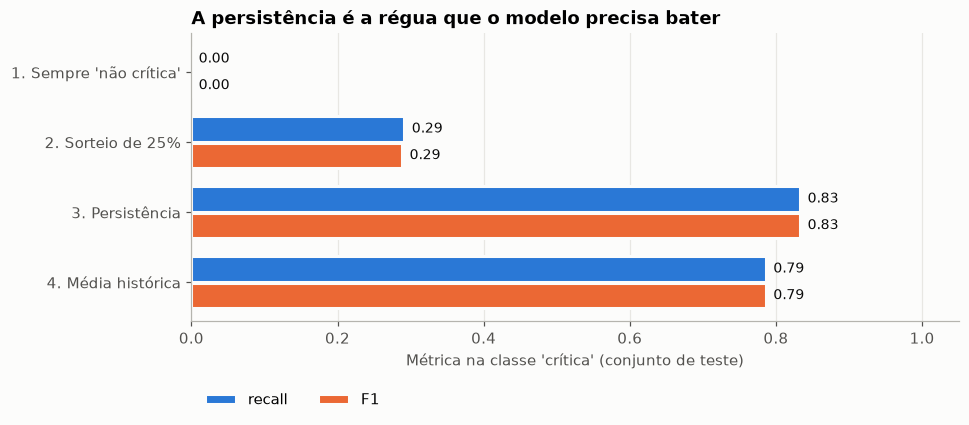

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.4))
nomes = resultado.index
y = np.arange(len(nomes))
ax.barh(y - 0.19, resultado["recall (críticas encontradas)"], height=0.36, color=AZUL, edgecolor=FUNDO, linewidth=2, label="recall")
ax.barh(y + 0.19, resultado["F1"], height=0.36, color=LARANJA, edgecolor=FUNDO, linewidth=2, label="F1")
for yi, (r, f) in enumerate(zip(resultado["recall (críticas encontradas)"], resultado["F1"])):
    ax.text(r + 0.01, yi - 0.19, f"{r:.2f}", va="center", fontsize=9, color=TEXTO)
    ax.text(f + 0.01, yi + 0.19, f"{f:.2f}", va="center", fontsize=9, color=TEXTO)
ax.set_yticks(y, nomes)
ax.invert_yaxis()
ax.set_xlim(0, 1.05)
ax.set_xlabel("Métrica na classe 'crítica' (conjunto de teste)")
ax.set_title("A persistência é a régua que o modelo precisa bater")
ax.legend(frameon=False, ncol=2, loc="upper left", bbox_to_anchor=(0, -0.2))
ax.grid(axis="y", visible=False)
salvar(fig, "09_baselines")
plt.show()

**Leitura:**
- **"Sempre não crítica" tem 75% de acurácia e zero utilidade**: acerta porque 75% das equipes não são críticas, mas não encontra nenhuma. É por isso que **acurácia não é a métrica** deste problema.
- **O sorteio** encontra só ~29% das críticas.
- **A persistência encontra 83%** das críticas. É uma régua alta, porque a qualidade do registro muda devagar (o notebook 01 mostrou que 78% das críticas continuam críticas).
- **A média histórica fica um pouco abaixo** da persistência: o passado distante ajuda menos que o presente.

## 4. Onde a persistência erra

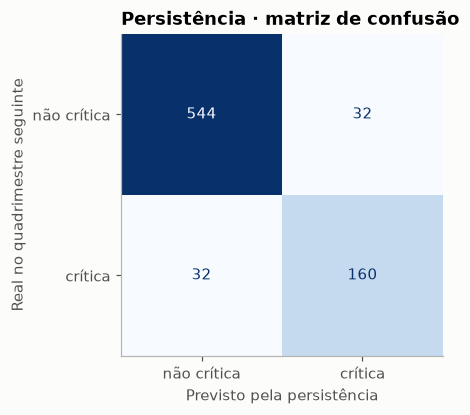

In [7]:
cm = confusion_matrix(teste[ALVO], teste["critica"])
fig, ax = plt.subplots(figsize=(4.6, 3.8))
ConfusionMatrixDisplay(cm, display_labels=["não crítica", "crítica"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_xlabel("Previsto pela persistência")
ax.set_ylabel("Real no quadrimestre seguinte")
ax.set_title("Persistência · matriz de confusão")
ax.grid(False)
salvar(fig, "10_matriz_persistencia")
plt.show()

In [8]:
entraram = teste[(teste[ALVO] == 1) & (teste["critica"] == 0)]
sairam = teste[(teste[ALVO] == 0) & (teste["critica"] == 1)]
print(f"Equipes que VIRARAM críticas (a persistência não vê nenhuma): {len(entraram)}")
print(f"Equipes que DEIXARAM de ser críticas (alarme falso da persistência): {len(sairam)}")

comparar = pd.DataFrame({
    "viraram críticas": entraram[["indice_completude", "posicao_na_rede", "variacao_indice", "media_historica"]].mean(),
    "continuaram bem": teste[(teste[ALVO] == 0) & (teste["critica"] == 0)][["indice_completude", "posicao_na_rede", "variacao_indice", "media_historica"]].mean(),
}).round(2)
comparar

Equipes que VIRARAM críticas (a persistência não vê nenhuma): 32
Equipes que DEIXARAM de ser críticas (alarme falso da persistência): 32


,viraram críticas,continuaram bem
indice_completude,53.45,65.48
posicao_na_rede,0.32,0.64
variacao_indice,1.13,0.82
media_historica,54.71,64.00


**Leitura:** a persistência, por definição, **nunca antecipa uma equipe que está piorando**: ela só repete o presente. As equipes que viraram críticas já estavam, em média, **mais perto da linha de corte** e com **média histórica mais baixa** do que as que continuaram bem.

**É exatamente esse espaço que um modelo pode ocupar**: combinar a situação atual com o histórico (quem está perto da linha e tem média baixa) para antecipar quem vai entrar na lista, que é o que a Secretaria precisa para planejar a formação antes do problema.

## 5. Próximos passos (Sprint 1 · 17/10)

| Etapa | O que fazer |
|---|---|
| Modelos iniciais | KNN, árvore de decisão e regressão logística, treinados com as variáveis acima |
| Comparação | Recall e F1 na classe "crítica", **sempre contra a persistência (F1 = 0,83)** |
| Critério de sucesso | Superar a persistência, principalmente nas equipes que viram críticas |
| Sprint 2 | Validação cruzada **temporal** (janela deslizante, nunca embaralhada) |